In [4]:
%pip install seaborn scikit-learn pandas numpy matplotlib


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 4.7 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 8.4 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 10.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# 1. Задание random_state и генерация датасета dfS00
np.random.seed(42)

# Матрица средних (4 признака)
means = [0, 0, 0, 0]

# Ковариационная матрица с r(A, B) = +0.9
cov_matrix = [
    [1.0, 0.9, 0.0, 0.0],  # A
    [0.9, 1.0, 0.0, 0.0],  # B
    [0.0, 0.0, 1.0, 0.0],  # C
    [0.0, 0.0, 0.0, 1.0]   # D
]

# Генерация 1000 объектов
data = np.random.multivariate_normal(mean=means, cov=cov_matrix, size=1000)

dfS00 = pd.DataFrame(data, columns=['A', 'B', 'C', 'D'])
dfS00['Class'] = 'Class_1'  # 1 класс размером 1000 объектов
print(dfS00)

            A         B         C         D    Class
0   -0.824697 -0.143577  0.647689 -0.138264  Class_1
1    0.056621  0.399828  1.579213 -0.234137  Class_1
2    0.561727  0.353447 -0.463418  0.542560  Class_1
3   -0.110104 -0.361567 -1.724918 -1.913280  Class_1
4    1.302986  0.671385 -0.908024  0.314247  Class_1
..        ...       ...       ...       ...      ...
995 -1.076841 -1.579283  3.152057  1.640615  Class_1
996 -0.114151 -0.359313  0.553149 -2.082099  Class_1
997 -1.769365 -1.980121 -1.689183 -0.774615  Class_1
998  1.919104  1.931831 -2.065083  0.751099  Class_1
999  1.944557  2.105844  1.643378 -0.320298  Class_1

[1000 rows x 5 columns]


In [3]:
def get_dataset_stats(df, class_col='Class'):
    print("=== [1.2] СТАТИСТИКА ПО ДАТАСЕТУ ===")
    print(f"Размерность датасета: {df.shape[0]} объектов, {df.shape[1]} признаков (включая класс)\n")
    
    print("--- Типы признаков ---")
    print(df.dtypes, "\n")
    
    print("--- Распределение объектов по классам ---")
    print(df[class_col].value_counts(), "\n")
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Подсчет NaN и 0 по классам
    nan_by_class = df.groupby(class_col)[numeric_cols].apply(lambda x: x.isna().sum())
    zero_by_class = df.groupby(class_col)[numeric_cols].apply(lambda x: (x == 0).sum())
    
    print("--- Число объектов с NaN по классам ---")
    print(nan_by_class, "\n")
    
    print("--- Число объектов с 0 по классам ---")
    print(zero_by_class, "\n")
    
    print("--- Основные статичтические оценки (Mean, Std, Median, IQR, Range) ---")
    stats_df = df[numeric_cols].describe().T
    stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
    stats_df['Range'] = stats_df['max'] - stats_df['min']
    print(stats_df[['mean', 'std', 'min', '50%', 'max', 'IQR', 'Range']])

get_dataset_stats(dfS00)

=== [1.2] СТАТИСТИКА ПО ДАТАСЕТУ ===
Размерность датасета: 1000 объектов, 5 признаков (включая класс)

--- Типы признаков ---
A        float64
B        float64
C        float64
D        float64
Class        str
dtype: object 

--- Распределение объектов по классам ---
Class
Class_1    1000
Name: count, dtype: int64 

--- Число объектов с NaN по классам ---
         A  B  C  D
Class              
Class_1  0  0  0  0 

--- Число объектов с 0 по классам ---
         A  B  C  D
Class              
Class_1  0  0  0  0 

--- Основные статичтические оценки (Mean, Std, Median, IQR, Range) ---
       mean       std       min       50%       max       IQR     Range
A -0.036576  0.961073 -3.137198 -0.038811  3.198146  1.257102  6.335344
B -0.023121  0.971135 -3.184754 -0.031887  3.220093  1.292792  6.404847
C -0.008255  1.006075 -3.241267 -0.007509  3.152057  1.317581  6.393324
D  0.024828  1.011884 -2.896255  0.020210  3.852731  1.370918  6.748987


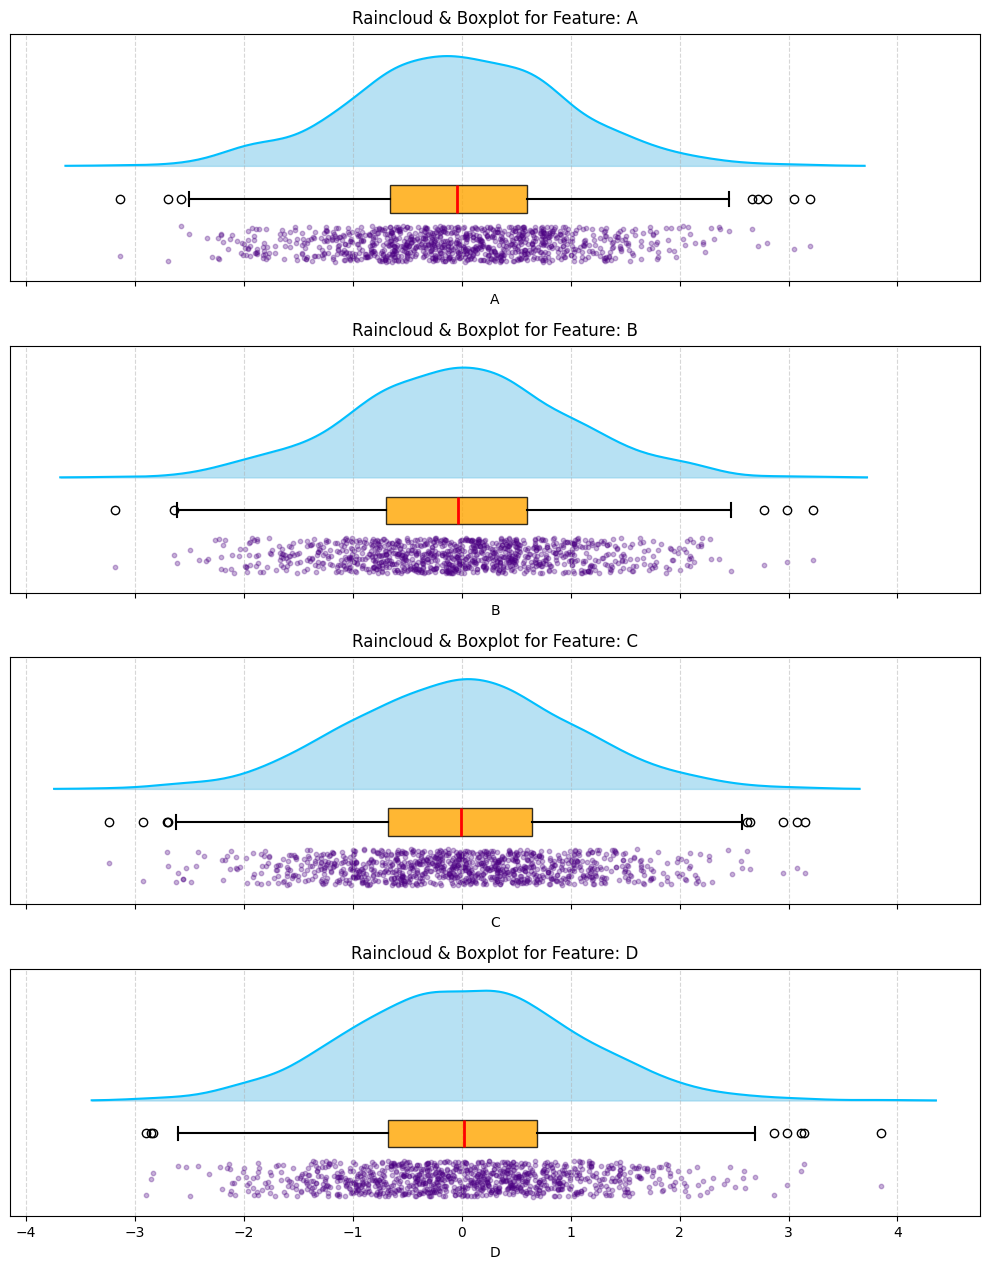

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
def plot_raincloud(df, features=['A', 'B', 'C', 'D']):
    fig, axes = plt.subplots(len(features), 1, figsize=(10, 3.2 * len(features)), sharex=True)
    if len(features) == 1: 
        axes = [axes]
    
    for i, col in enumerate(features):
        ax = axes[i]
        vals = df[col].dropna()
        
        # 1. CLOUD (Облако плотности через KDE)
        kde = gaussian_kde(vals)
        x_grid = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 200)
        y_kde = kde(x_grid)
        # Нормализуем высоту облака для аккуратного отображения над осью (от 0 до 0.4)
        y_kde_norm = y_kde / y_kde.max() * 0.4
        
        ax.fill_between(x_grid, 0, y_kde_norm, color='skyblue', alpha=0.6, label='Density')
        ax.plot(x_grid, y_kde_norm, color='deepskyblue', lw=1.5)
        
        # 2. BOXPLOT (Медиана, IQR, Range) — смещен чуть ниже нуля (-0.15)
        ax.boxplot(vals, vert=False, positions=[-0.12], widths=0.1,
                   patch_artist=True,
                   boxprops=dict(facecolor='orange', color='black', alpha=0.8),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='black', linewidth=1.5),
                   capprops=dict(color='black', linewidth=1.5))
        
        # 3. RAIN (Точки с джиттерингом/разбросом) — расположены еще ниже (-0.3)
        jitter = np.random.uniform(-0.35, -0.22, size=len(vals))
        ax.scatter(vals, jitter, color='indigo', alpha=0.3, s=10)
        
        # Настройка осей и оформления
        ax.set_title(f"Raincloud & Boxplot for Feature: {col}", fontsize=12, pad=8)
        ax.set_yticks([])  # Скрываем искусственные координаты по Y
        ax.set_ylim(-0.42, 0.48)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlabel(col)
        
    plt.tight_layout()
    plt.show()

# Запуск исправленной функции
plot_raincloud(dfS00)

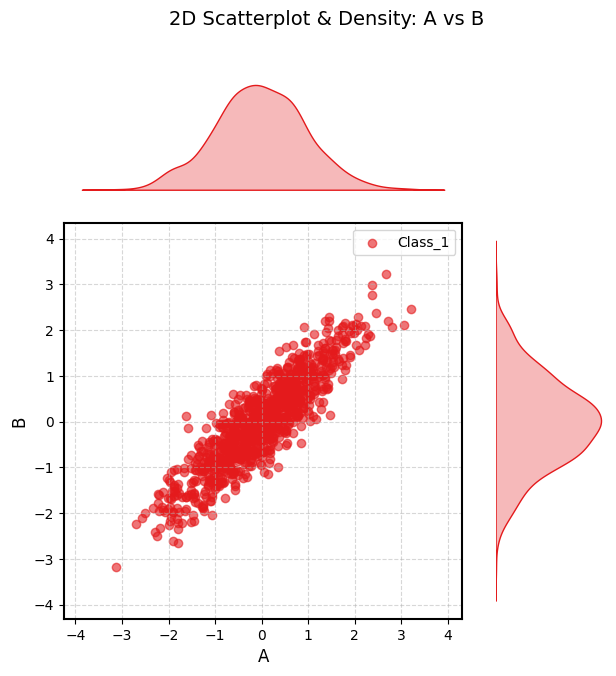

In [8]:
def plot_2d_scatter_and_density(df, x_col='A', y_col='B', class_col='Class',
                                color_axes='black', lw_axes=1.5,
                                grid=True, aspect_square=True,
                                font_size_labels=12, font_size_title=14,
                                show_legend=True, show_title=True, alpha=0.6):
    
    fig = plt.figure(figsize=(7, 7) if aspect_square else (9, 6))
    grid_spec = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)
    
    # Главный scatterplot
    ax_scatter = fig.add_subplot(grid_spec[1:, :-1])
    # Плотности по осям X и Y
    ax_hist_x = fig.add_subplot(grid_spec[0, :-1], sharex=ax_scatter)
    ax_hist_y = fig.add_subplot(grid_spec[1:, -1], sharey=ax_scatter)
    
    classes = df[class_col].unique()
    palette = sns.color_palette("Set1", len(classes))
    markers = ['o', 's', '^', 'D', 'v']
    
    for idx, cls in enumerate(classes):
        sub_df = df[df[class_col] == cls]
        
        # Scatterplot
        ax_scatter.scatter(sub_df[x_col], sub_df[y_col], 
                           color=palette[idx], marker=markers[idx % len(markers)],
                           alpha=alpha, label=str(cls))
        
        # Marginal Density X
        sns.kdeplot(sub_df[x_col], ax=ax_hist_x, color=palette[idx], fill=True, alpha=0.3)
        # Marginal Density Y
        sns.kdeplot(y=sub_df[y_col], ax=ax_hist_y, color=palette[idx], fill=True, alpha=0.3)
    
    # Кастомизация осей
    for ax in [ax_scatter, ax_hist_x, ax_hist_y]:
        for spine in ax.spines.values():
            spine.set_color(color_axes)
            spine.set_linewidth(lw_axes)
            
    ax_scatter.grid(grid, linestyle='--', alpha=0.5)
    ax_scatter.set_xlabel(x_col, fontsize=font_size_labels)
    ax_scatter.set_ylabel(y_col, fontsize=font_size_labels)
    
    ax_hist_x.axis('off')
    ax_hist_y.axis('off')
    
    if show_legend and class_col in df.columns:
        ax_scatter.legend(fontsize=font_size_labels - 2)
        
    if show_title:
        fig.suptitle(f"2D Scatterplot & Density: {x_col} vs {y_col}", fontsize=font_size_title)
        
    plt.show()

plot_2d_scatter_and_density(dfS00, x_col='A', y_col='B')

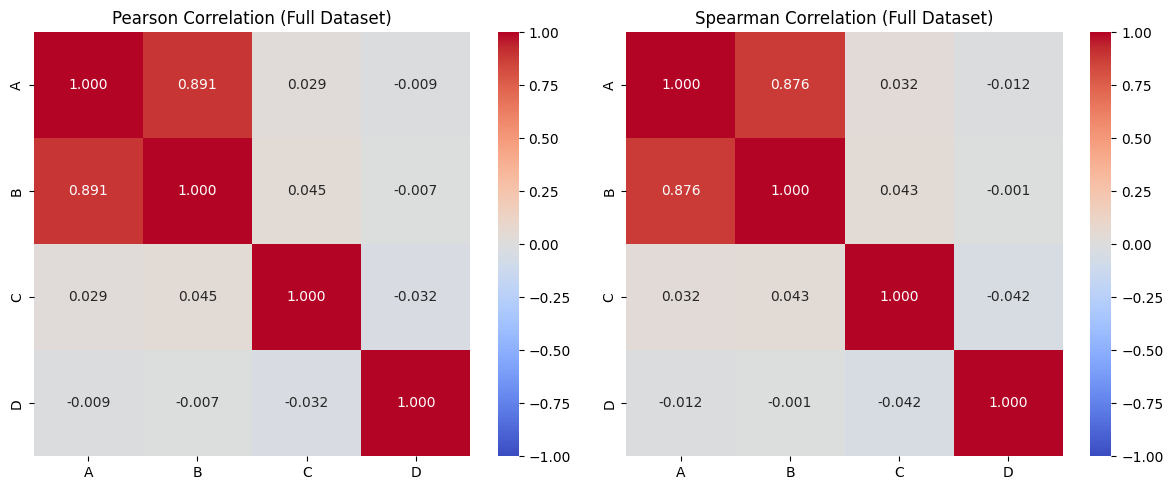

In [9]:
def plot_correlation_heatmaps(df, class_col='Class'):
    num_cols = df.select_dtypes(include=[np.number]).columns
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Пирсон
    p_corr = df[num_cols].corr(method='pearson')
    sns.heatmap(p_corr, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title("Pearson Correlation (Full Dataset)")
    
    # Спирман
    s_corr = df[num_cols].corr(method='spearman')
    sns.heatmap(s_corr, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title("Spearman Correlation (Full Dataset)")
    
    plt.tight_layout()
    plt.show()

plot_correlation_heatmaps(dfS00)

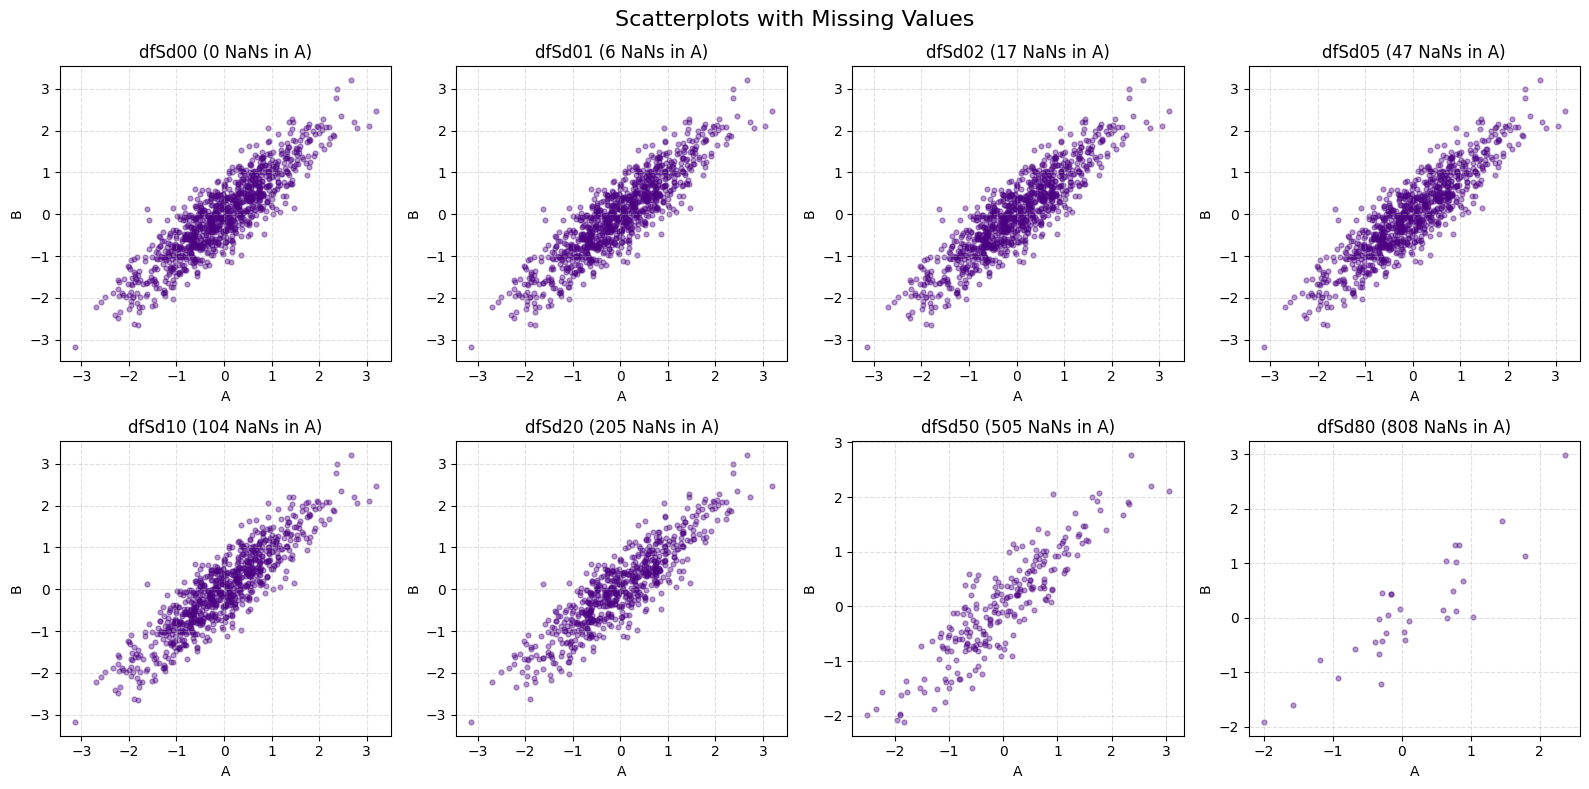

In [10]:
def generate_missing_datasets(df_orig, percentages=[0, 1, 2, 5, 10, 20, 50, 80]):
    datasets = {}
    num_cols = ['A', 'B', 'C', 'D']
    total_cells = df_orig[num_cols].size
    
    for p in percentages:
        df_copy = df_orig.copy()
        if p > 0:
            n_missing = int(total_cells * (p / 100.0))
            mask = np.zeros(total_cells, dtype=bool)
            mask[:n_missing] = True
            np.random.shuffle(mask)
            mask = mask.reshape(df_orig[num_cols].shape)
            
            # Вставляем NaN по маске MCAR
            for i, col in enumerate(num_cols):
                df_copy.loc[mask[:, i], col] = np.nan
                
        datasets[f"dfSd{p:02d}"] = df_copy
    return datasets

df_missing_dict = generate_missing_datasets(dfS00)

def plot_panel_scatterplots(datasets_dict, pair=('A', 'B'), title="Scatterplots with Missing Values"):
    n_items = len(datasets_dict)
    rows, cols = 2, 4
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, (name, df) in enumerate(datasets_dict.items()):
        ax = axes[idx]
        ax.scatter(df[pair[0]], df[pair[1]], alpha=0.4, color='indigo', s=12)
        ax.set_title(f"{name} ({df[pair[0]].isna().sum()} NaNs in {pair[0]})")
        ax.set_xlabel(pair[0])
        ax.set_ylabel(pair[1])
        ax.grid(True, linestyle='--', alpha=0.4)
        
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_panel_scatterplots(df_missing_dict, pair=('A', 'B'))

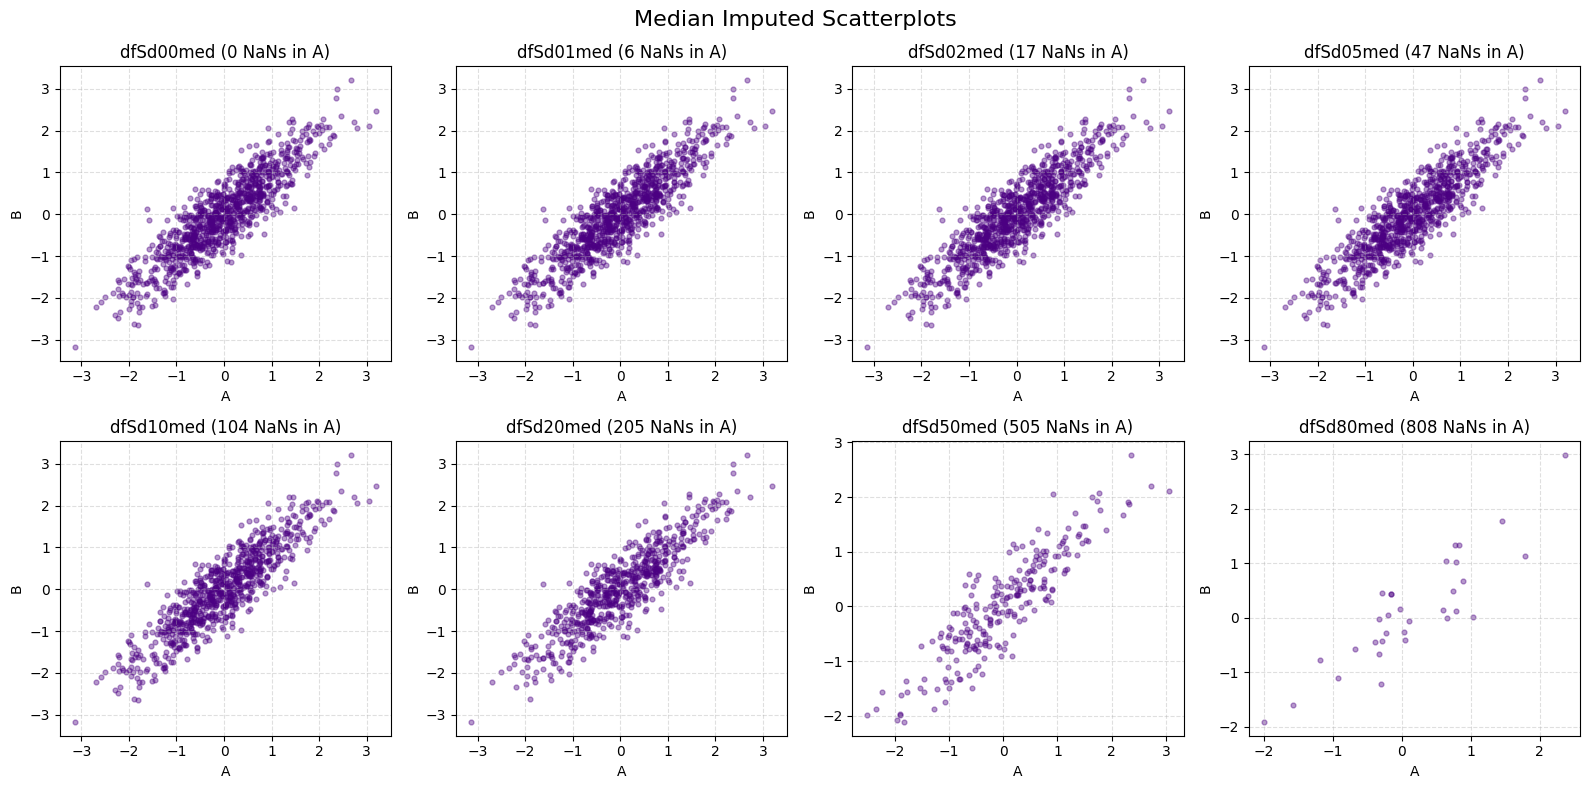

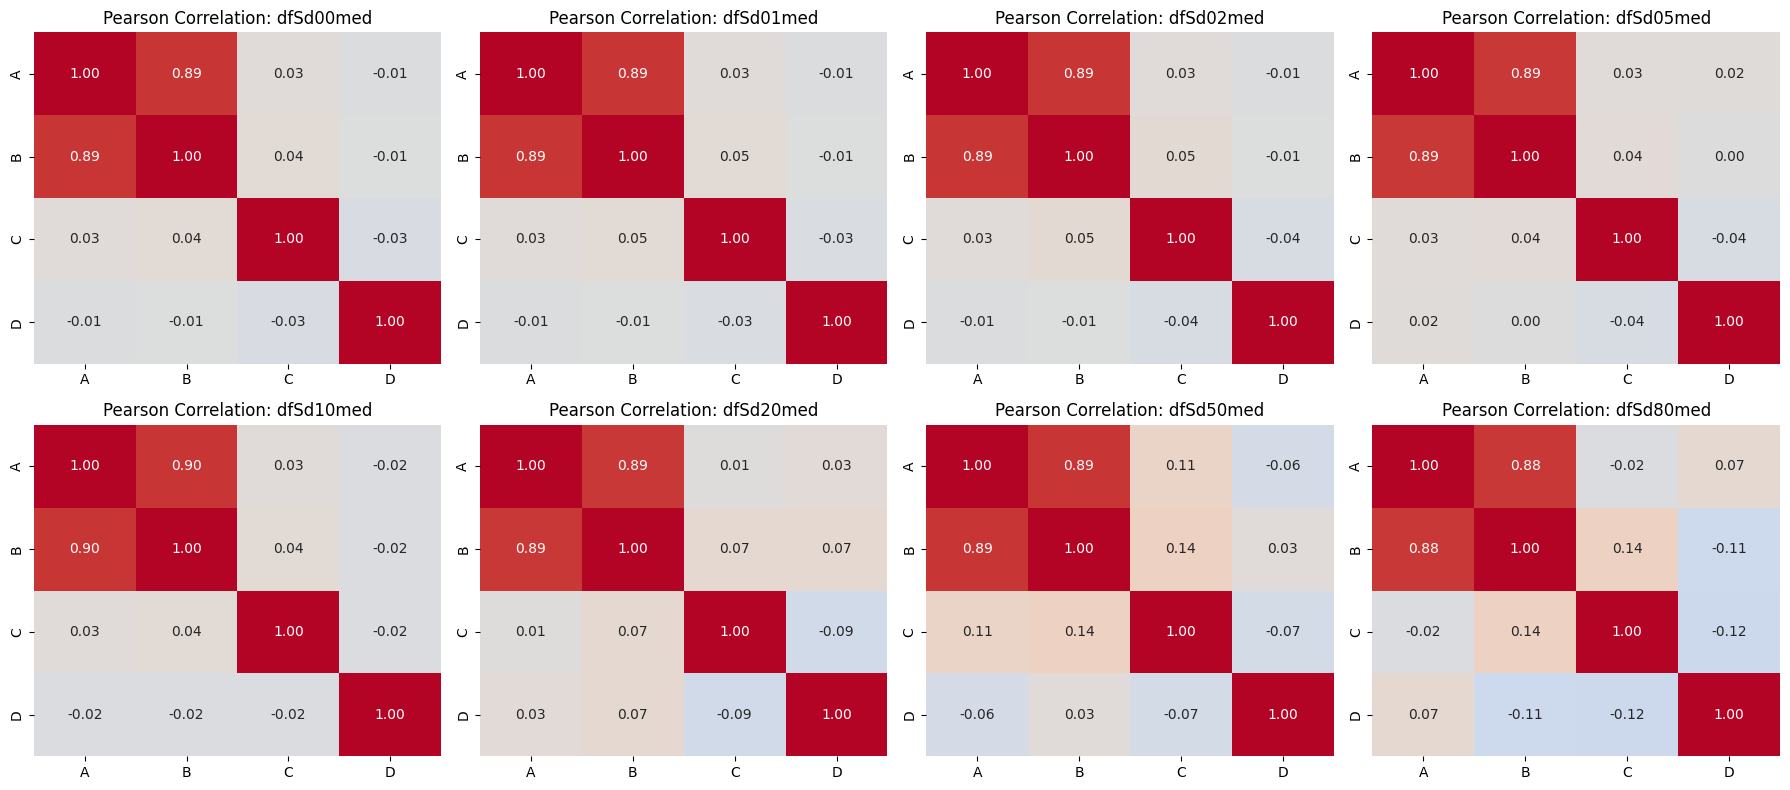

In [11]:
df_med_dict = {}
for name, df in df_missing_dict.items():
    df_imputed = df.copy()
    for col in ['A', 'B', 'C', 'D']:
        df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
    df_med_dict[name + "med"] = df_imputed

plot_panel_scatterplots(df_med_dict, pair=('A', 'B'), title="Median Imputed Scatterplots")

# Вывод Heatmap корреляций Пирсона
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (name, df) in enumerate(df_med_dict.items()):
    ax = axes[idx]
    sns.heatmap(df[['A', 'B', 'C', 'D']].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=ax, cbar=False)
    ax.set_title(f"Pearson Correlation: {name}")

plt.tight_layout()
plt.show()

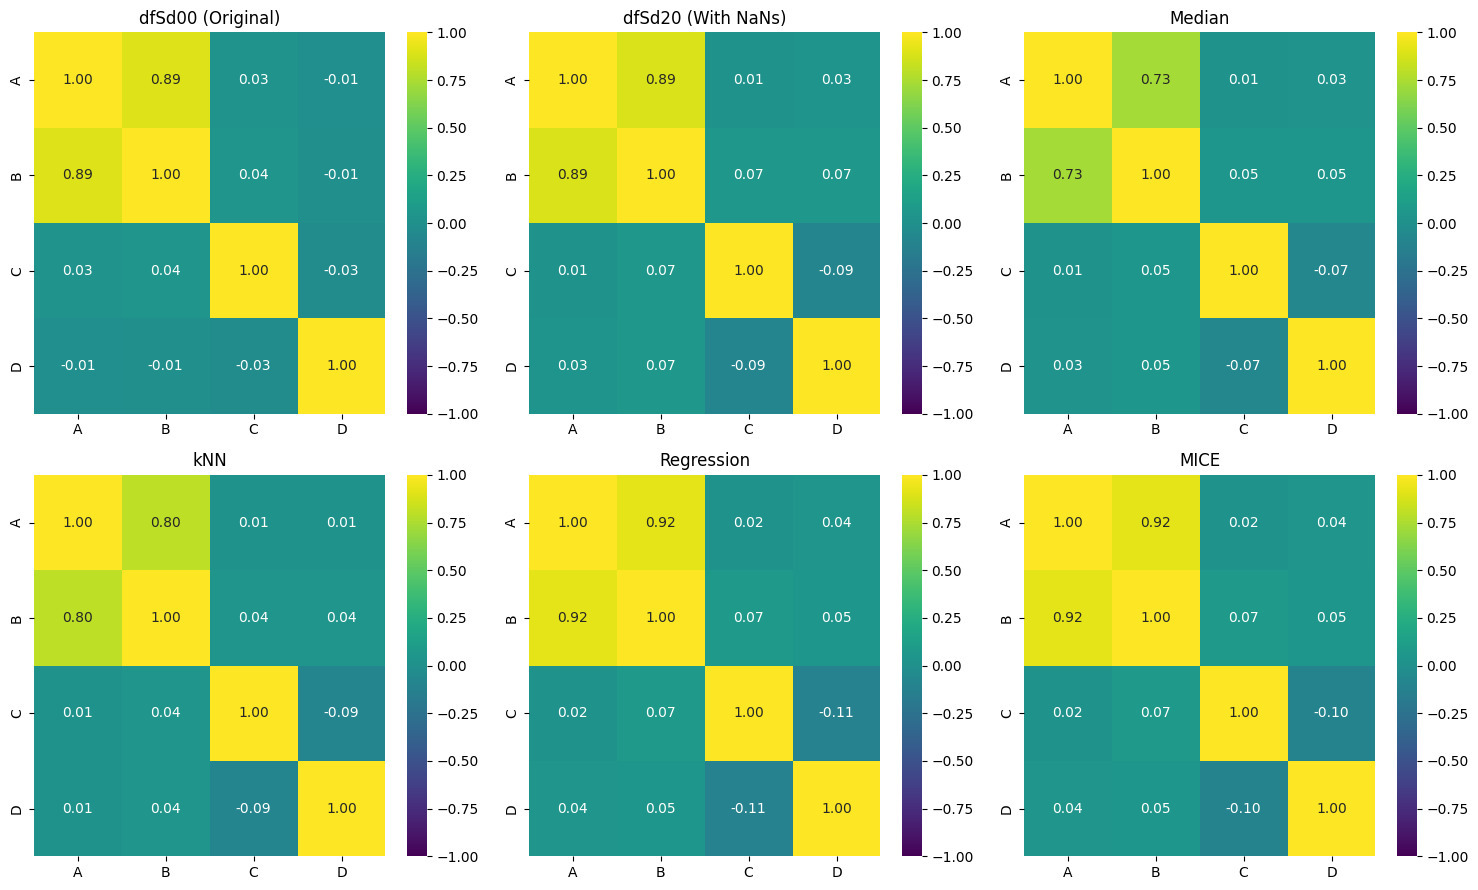

In [12]:
selected_key = 'dfSd20'  # Выбран датасет с 20% пропусков
df_target = df_missing_dict[selected_key].copy()
num_cols = ['A', 'B', 'C', 'D']

imputed_methods = {}

# 1. Median
df_med = df_target.copy()
df_med[num_cols] = df_med[num_cols].fillna(df_med[num_cols].median())
imputed_methods['Median'] = df_med

# 2. kNN Imputation
knn_imp = KNNImputer(n_neighbors=5)
df_knn = df_target.copy()
df_knn[num_cols] = knn_imp.fit_transform(df_target[num_cols])
imputed_methods['kNN'] = df_knn

# 3. Regression Imputation
reg_imp = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=42)
df_reg = df_target.copy()
df_reg[num_cols] = reg_imp.fit_transform(df_target[num_cols])
imputed_methods['Regression'] = df_reg

# 4. MICE Imputation
mice_imp = IterativeImputer(max_iter=20, random_state=42)
df_mice = df_target.copy()
df_mice[num_cols] = mice_imp.fit_transform(df_target[num_cols])
imputed_methods['MICE'] = df_mice

# Визуализация корреляционных матриц
all_comparisons = {'dfSd00 (Original)': dfS00, selected_key + ' (With NaNs)': df_target}
all_comparisons.update(imputed_methods)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, df) in enumerate(all_comparisons.items()):
    ax = axes[idx]
    sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='viridis', vmin=-1, vmax=1, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

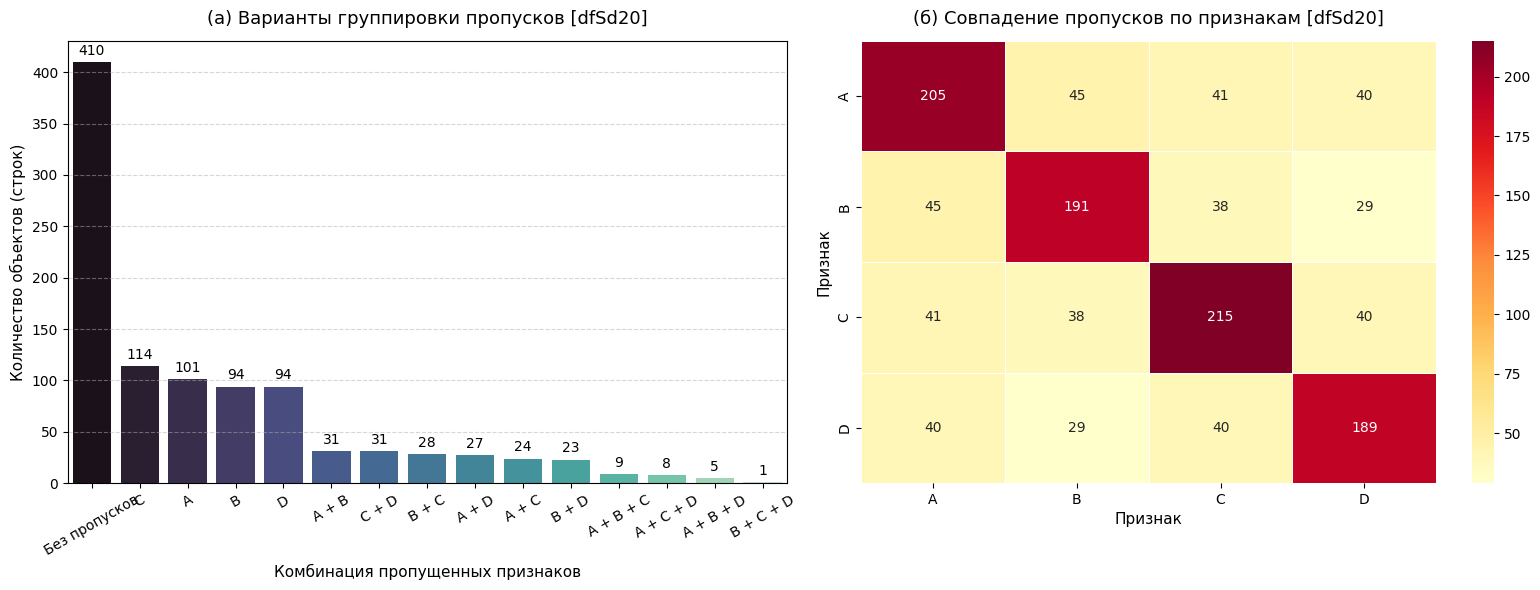

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_missing_analysis_1_9(df, features=['A', 'B', 'C', 'D'], dataset_name="dfSd20"):
    """
    [1.9] Визуализация шаблонов пропусков без библиотеки upsetplot:
    (а) Числа объектов с пропущенными значениями для всех вариантов группировки
    (б) Матрица совпадений пропущенных значений по парам признаков
    """
    # Булева матрица пропусков (True — NaN, False — есть значение)
    nan_mask = df[features].isna()
    
    if nan_mask.sum().sum() == 0:
        print(f"В датасете {dataset_name} нет пропущенных значений.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # -------------------------------------------------------------------
    # ЧАСТЬ (а): Числа объектов для всех вариантов группировки пропусков
    # -------------------------------------------------------------------
    # Группируем по комбинациям True/False во всех столбцах
    pattern_counts = nan_mask.groupby(features, observed=False).size().reset_index(name='Count')
    
    # Формируем читаемую подпись группы (например: "A + B", "Только C" или "Без пропусков")
    def format_pattern(row):
        missing_cols = [col for col in features if row[col]]
        return " + ".join(missing_cols) if missing_cols else "Без пропусков"

    pattern_counts['Pattern'] = pattern_counts.apply(format_pattern, axis=1)
    pattern_counts = pattern_counts.sort_values(by='Count', ascending=False)

    # Строим диаграмму вариантов группировки
    ax1 = sns.barplot(data=pattern_counts, x='Pattern', y='Count', palette='mako', ax=axes[0])
    axes[0].set_title(f"(а) Варианты группировки пропусков [{dataset_name}]", fontsize=13, pad=12)
    axes[0].set_xlabel("Комбинация пропущенных признаков", fontsize=11)
    axes[0].set_ylabel("Количество объектов (строк)", fontsize=11)
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Отображение точных чисел над столбцами
    for p in ax1.patches:
        height = p.get_height()
        if height > 0:
            ax1.annotate(f"{int(height)}", 
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=10, xytext=(0, 3), 
                         textcoords='offset points')

    # -------------------------------------------------------------------
    # ЧАСТЬ (б): Числа объектов с совпадающими пропусками по признакам
    # -------------------------------------------------------------------
    # Умножение матрицы маски самой на себя дает число совпадающих пропусков для каждой пары
    co_occurrence = nan_mask.astype(int).T.dot(nan_mask.astype(int))
    
    sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd', cbar=True, ax=axes[1], linewidths=0.5)
    axes[1].set_title(f"(б) Совпадение пропусков по признакам [{dataset_name}]", fontsize=13, pad=12)
    axes[1].set_xlabel("Признак", fontsize=11)
    axes[1].set_ylabel("Признак", fontsize=11)

    plt.tight_layout()
    plt.show()

# Вызов функции для любого датасета с пропусками (например, dfSd20 или dfMNAR)
plot_missing_analysis_1_9(df_missing_dict['dfSd20'], dataset_name="dfSd20")

=== [1.10] СТАТИСТИКА ПРОПУСКОВ B dfMNAR ===
A      0
B      0
C    500
D    500
dtype: int64


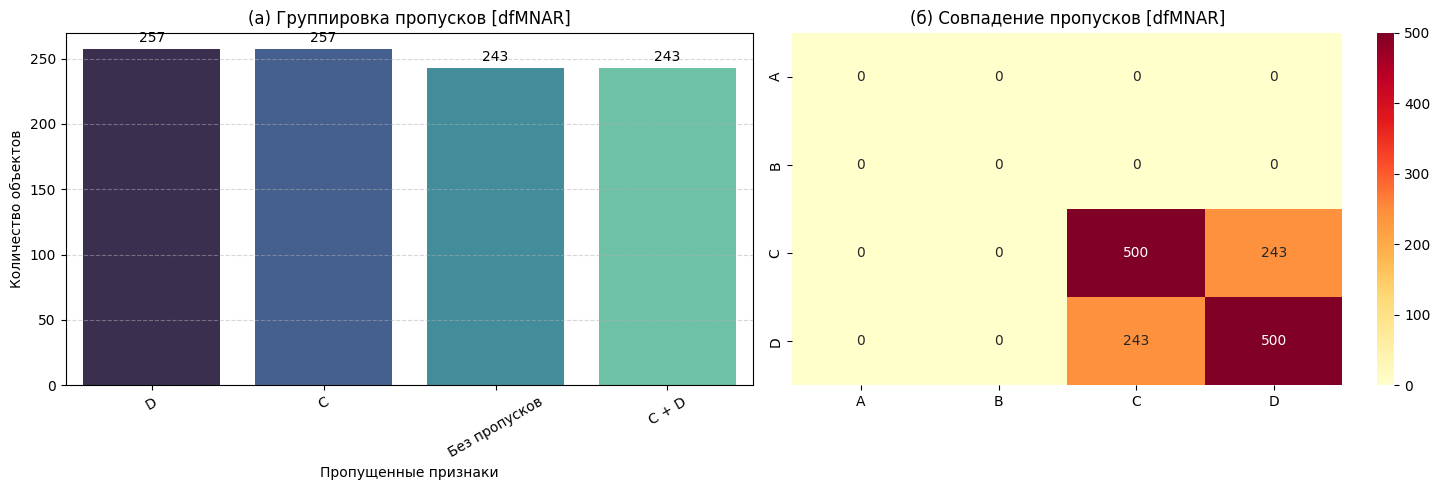

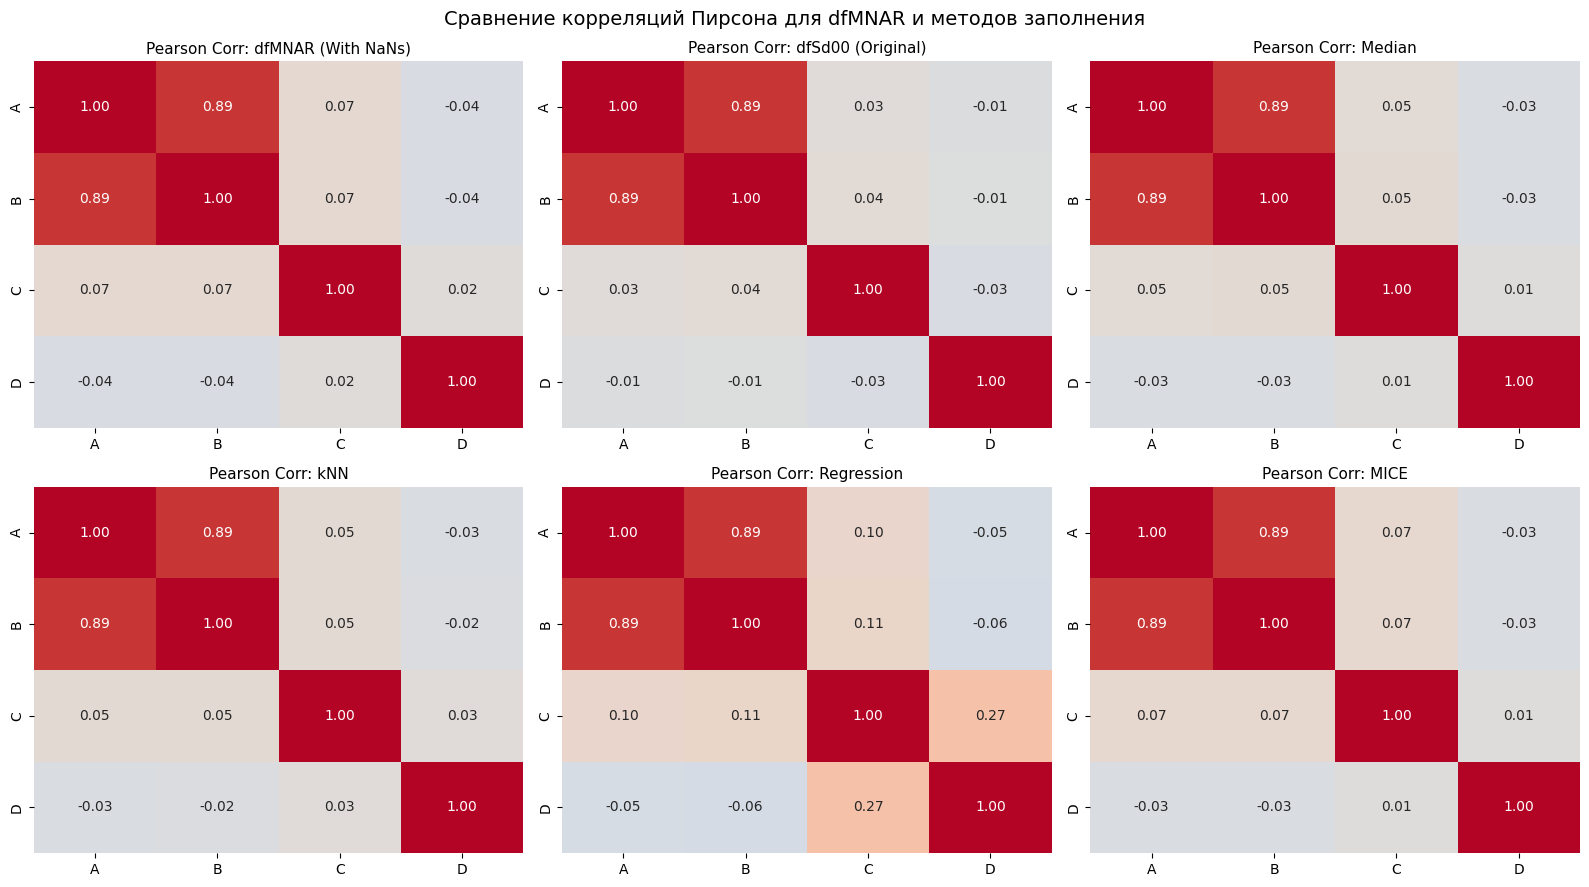

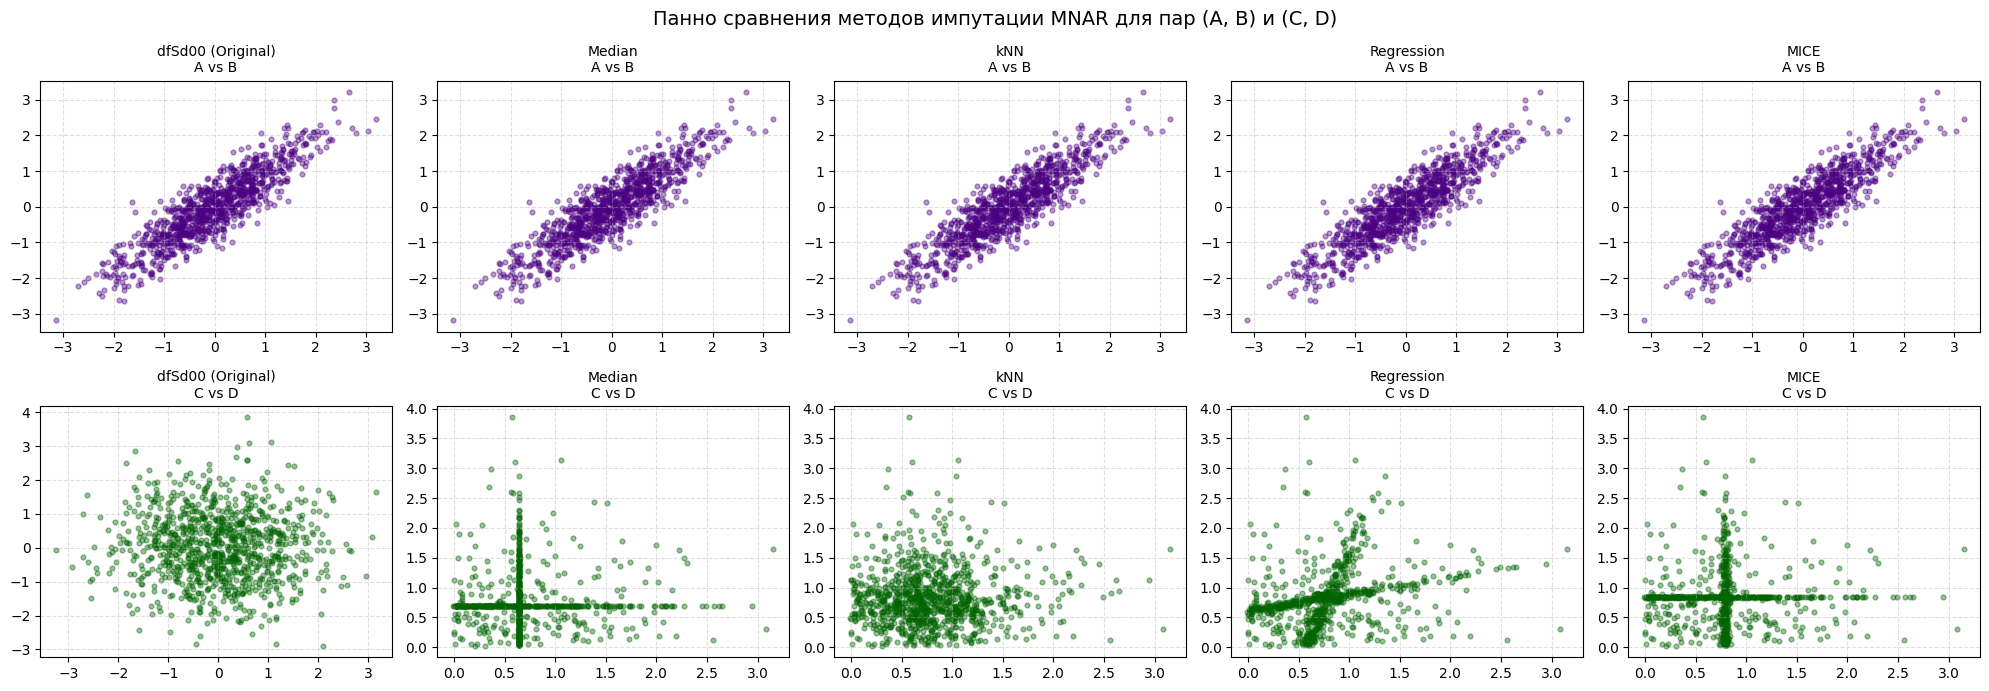

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

# =====================================================================
# 1. СОЗДАНИЕ ДАТАСЕТА dfMNAR (Missing Not At Random)
# =====================================================================
dfMNAR = dfS00.copy()

# Удаляем значения C и D, если они меньше медианы соответствующего признака
med_C = dfMNAR['C'].median()
med_D = dfMNAR['D'].median()

dfMNAR.loc[dfMNAR['C'] < med_C, 'C'] = np.nan
dfMNAR.loc[dfMNAR['D'] < med_D, 'D'] = np.nan

print("=== [1.10] СТАТИСТИКА ПРОПУСКОВ B dfMNAR ===")
print(dfMNAR[['A', 'B', 'C', 'D']].isna().sum())


# =====================================================================
# 2. АНАЛИЗ ПРОПУСКОВ ИЗ ПУНКТА [1.9] (Без использования upsetplot)
# =====================================================================
def plot_missing_analysis_mnar(df, features=['A', 'B', 'C', 'D'], title="dfMNAR"):
    nan_mask = df[features].isna()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # (а) Варианты группировки пропусков
    pattern_counts = nan_mask.groupby(features, observed=False).size().reset_index(name='Count')
    
    def format_pattern(row):
        missing_cols = [col for col in features if row[col]]
        return " + ".join(missing_cols) if missing_cols else "Без пропусков"

    pattern_counts['Pattern'] = pattern_counts.apply(format_pattern, axis=1)
    pattern_counts = pattern_counts.sort_values(by='Count', ascending=False)

    ax1 = sns.barplot(data=pattern_counts, x='Pattern', y='Count', palette='mako', ax=axes[0])
    axes[0].set_title(f"(а) Группировка пропусков [{title}]", fontsize=12)
    axes[0].set_xlabel("Пропущенные признаки")
    axes[0].set_ylabel("Количество объектов")
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    for p in ax1.patches:
        h = p.get_height()
        if h > 0:
            ax1.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2., h),
                         ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

    # (б) Матрица совпадения пропусков по парам признаков
    co_occurrence = nan_mask.astype(int).T.dot(nan_mask.astype(int))
    sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], cbar=True)
    axes[1].set_title(f"(б) Совпадение пропусков [{title}]", fontsize=12)

    plt.tight_layout()
    plt.show()

# Запуск анализа пропусков для dfMNAR
plot_missing_analysis_mnar(dfMNAR, title="dfMNAR")


# =====================================================================
# 3. ИМПУТАЦИЯ 4 МЕТОДАМИ ИЗ ПУНКТА [1.8] ДЛЯ dfMNAR
# =====================================================================
num_cols = ['A', 'B', 'C', 'D']
mnar_imputed = {}

# Исходный датасет без пропусков
mnar_imputed['dfSd00 (Original)'] = dfS00

# 1. Median
df_med = dfMNAR.copy()
df_med[num_cols] = df_med[num_cols].fillna(df_med[num_cols].median())
mnar_imputed['Median'] = df_med

# 2. kNN Imputation
knn_imp = KNNImputer(n_neighbors=5)
df_knn = dfMNAR.copy()
df_knn[num_cols] = knn_imp.fit_transform(df_mnar_target := dfMNAR[num_cols].copy())
mnar_imputed['kNN'] = df_knn

# 3. Regression Imputation
reg_imp = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=42)
df_reg = dfMNAR.copy()
df_reg[num_cols] = reg_imp.fit_transform(dfMNAR[num_cols])
mnar_imputed['Regression'] = df_reg

# 4. MICE Imputation
mice_imp = IterativeImputer(max_iter=20, random_state=42)
df_mice = dfMNAR.copy()
df_mice[num_cols] = mice_imp.fit_transform(dfMNAR[num_cols])
mnar_imputed['MICE'] = df_mice


# =====================================================================
# 4. HEATMAP КОРРЕЛЯЦИЙ ПИРСOНА ДЛЯ ВСЕХ ВАРAИАНТОВ ИМПУТАЦИИ
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

all_mnar_cases = {'dfMNAR (With NaNs)': dfMNAR}
all_mnar_cases.update(mnar_imputed)

for idx, (name, df) in enumerate(all_mnar_cases.items()):
    ax = axes[idx]
    sns.heatmap(df[num_cols].corr(method='pearson'), annot=True, fmt=".2f", 
                cmap='coolwarm', vmin=-1, vmax=1, ax=ax, cbar=False)
    ax.set_title(f"Pearson Corr: {name}", fontsize=11)

plt.suptitle("Сравнение корреляций Пирсона для dfMNAR и методов заполнения", fontsize=14)
plt.tight_layout()
plt.show()


# =====================================================================
# 5. ПАННО $M \times N$ SCATTERPLOT ДЛЯ ДВУХ ПАР ПРИЗНАКОВ (A+B) и (C+D)
# =====================================================================
def plot_imputation_comparison_panel(imputed_dict, pair_1=('A', 'B'), pair_2=('C', 'D')):
    methods = list(imputed_dict.keys())
    fig, axes = plt.subplots(2, len(methods), figsize=(4 * len(methods), 7))

    for col_idx, name in enumerate(methods):
        df = imputed_dict[name]
        
        # Пара 1 (A + B)
        axes[0, col_idx].scatter(df[pair_1[0]], df[pair_1[1]], alpha=0.4, color='indigo', s=12)
        axes[0, col_idx].set_title(f"{name}\n{pair_1[0]} vs {pair_1[1]}", fontsize=10)
        axes[0, col_idx].grid(True, linestyle='--', alpha=0.4)
        
        # Пара 2 (C + D)
        axes[1, col_idx].scatter(df[pair_2[0]], df[pair_2[1]], alpha=0.4, color='darkgreen', s=12)
        axes[1, col_idx].set_title(f"{name}\n{pair_2[0]} vs {pair_2[1]}", fontsize=10)
        axes[1, col_idx].grid(True, linestyle='--', alpha=0.4)

    plt.suptitle("Панно сравнения методов импутации MNAR для пар (A, B) и (C, D)", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_imputation_comparison_panel(mnar_imputed)